In [ ]:
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

years = ['2009','2010','2011','2012','2013','2014','2015','2016','2017']
sexual  = [0]*9
kidnap  = [0]*9
murder  = [0]*9
robbery = [0]*9

# ==========================================================
# 2. 데이터 전처리 및 설계 
# ==========================================================

# (1) 2009~2010 : crime08-10.csv

f = open('crime08-10.csv', 'r', encoding='cp949')
data = csv.reader(f)
next(data); next(data); next(data); next(data)

idxs_0810 = [20, 37] # 2009,2010

for row in data:
    crime = row[2].strip()
    if crime == '소계' or crime == '계': 
        continue
        
    for i in range(2):
        v = row[idxs_0810[i]].strip()
        if v== '-': 
            v=0
        else: v=int(v)
        
        if crime == '강간': # 강간
            sexual[i] += v
        elif crime == '인질강요': # 유괴 
            kidnap[i] += v
        elif crime == '살인': # 살인
            murder[i] += v
        elif crime == '강도': # 강도
            robbery[i] += v
f.close()

# (2) 2011~2012 : crime11-12.csv

f = open('crime11-12.csv', 'r', encoding='cp949')
data = csv.reader(f)
next(data); next(data); next(data); next(data)

idxs_1112 = [2, 19] # 2011,2012

for row in data:
    crime = row[1].strip()    
    if crime == '소계' or crime == '계': 
        continue
        
    for i in range(2):
        v = row[idxs_1112[i]].strip()
        if v == '-': 
            v=0 
        else: v=int(v)
            
        j = i + 2
        if crime == '강간·강제추행': # 강간
            sexual[j] += v
        elif crime == '약취·유인': # 유괴 
            kidnap[j] += v
        elif crime in ['살인기수', '살인미수등']: # 살인
            murder[j] += v
        elif crime == '강도': # 강도
            robbery[j] += v            
f.close()

# (3) 2013~2017 : crime13-17.csv

f = open('crime13-17.csv', 'r', encoding='cp949')
data = csv.reader(f)
next(data); next(data); next(data); next(data)

idxs_1317 = [2, 19, 36, 53, 70] # 2013, 2014, 2015, 2016, 2017

for row in data:
    crime = row[1].strip()
    if crime == '소계' or crime == '계': 
        continue
        
    for i in range(5):
        v = row[idxs_1317[i]].strip() 
        if v== '-': 
            v=0
        else: v=int(v)
        
        j = i + 4
        if crime in ['강간', '강제추행', 
                     '기타 강간·강제추행등']: # 강간
            sexual[j] += v
        elif crime == '약취·유인': # 유괴
            kidnap[j] += v
        elif crime in ['살인기수', '살인미수등']: # 살인
            murder[j] += v
        elif crime == '강도': # 강도
            robbery[j] += v
f.close()

# ==========================================================
# 3. 데이터 변환 
# ==========================================================

df = pd.DataFrame({
    '성범죄': sexual,
    '유괴': kidnap,
    '살인': murder,
    '강도': robbery
}, index=years)

# 2013년 값을 기준으로 계산 (2013년=100)
df_indexed = round((df / df.loc['2013']) * 100,2)
df_indexed

,성범죄,유괴,살인,강도
2009,40.26,0.00,150.32,293.59
2010,75.07,0.00,133.65,186.86
2011,75.86,141.03,127.30,171.17
2012,83.92,118.80,107.46,126.71
2013,100.00,100.00,100.00,100.00
2014,97.07,105.13,95.87,80.23
2015,97.02,95.73,96.67,75.52
2016,102.61,115.38,94.60,66.24
2017,109.01,107.69,82.06,54.48


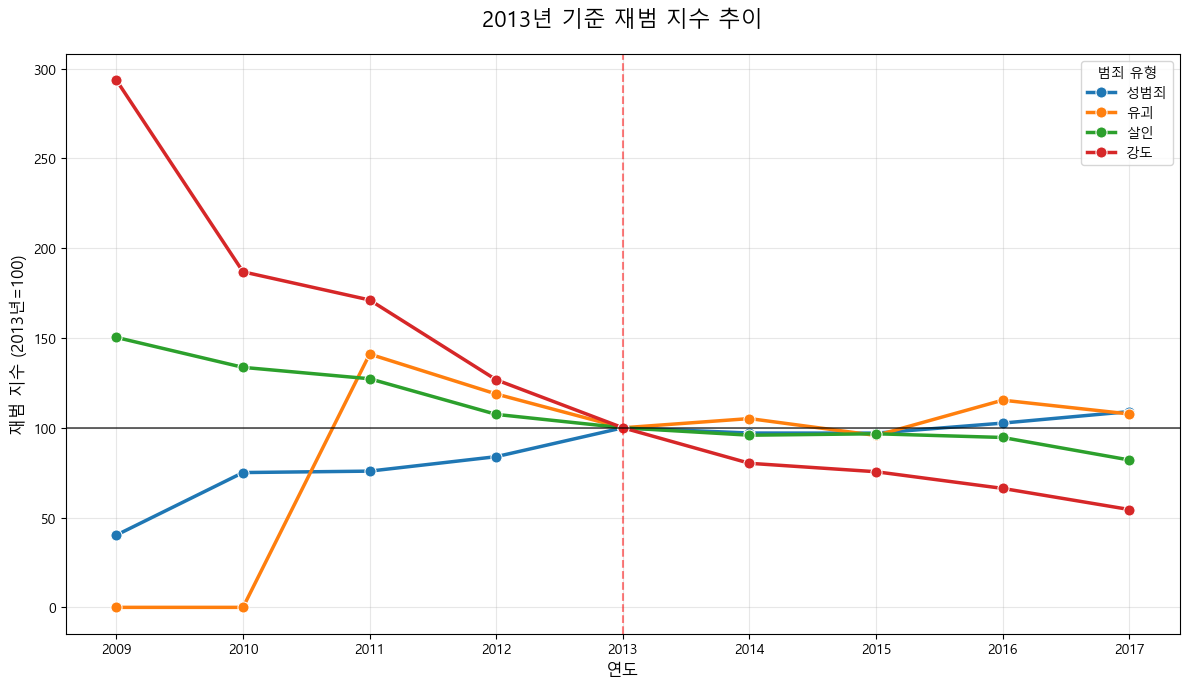

In [31]:
# ==========================================================
# 4. 시각화: 2013년 기준 재범 지수 추이
# ==========================================================

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 7))

sns.lineplot(data=df_indexed, marker='o', markersize=8, linewidth=2.5, dashes=False)

plt.axvline('2013', linestyle='--', color='red', alpha=0.5)
plt.axhline(100, color='black', linewidth=1.2, alpha=0.7)

plt.title('2013년 기준 재범 지수 추이', fontsize=16, pad=20)
plt.xlabel('연도', fontsize=12)
plt.ylabel('재범 지수 (2013년=100)', fontsize=12)

plt.grid(alpha=0.3)
plt.legend(title='범죄 유형')

plt.tight_layout()
plt.show()

연도: ['2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017']
성폭력: [4418, 8237, 8324, 9209, 10973, 10651, 10646, 11259, 11962]
유괴: [0, 0, 165, 139, 117, 123, 112, 135, 126]
살인: [947, 842, 802, 677, 630, 604, 609, 596, 517]
강도: [5540, 3526, 3230, 2391, 1887, 1514, 1425, 1250, 1028]


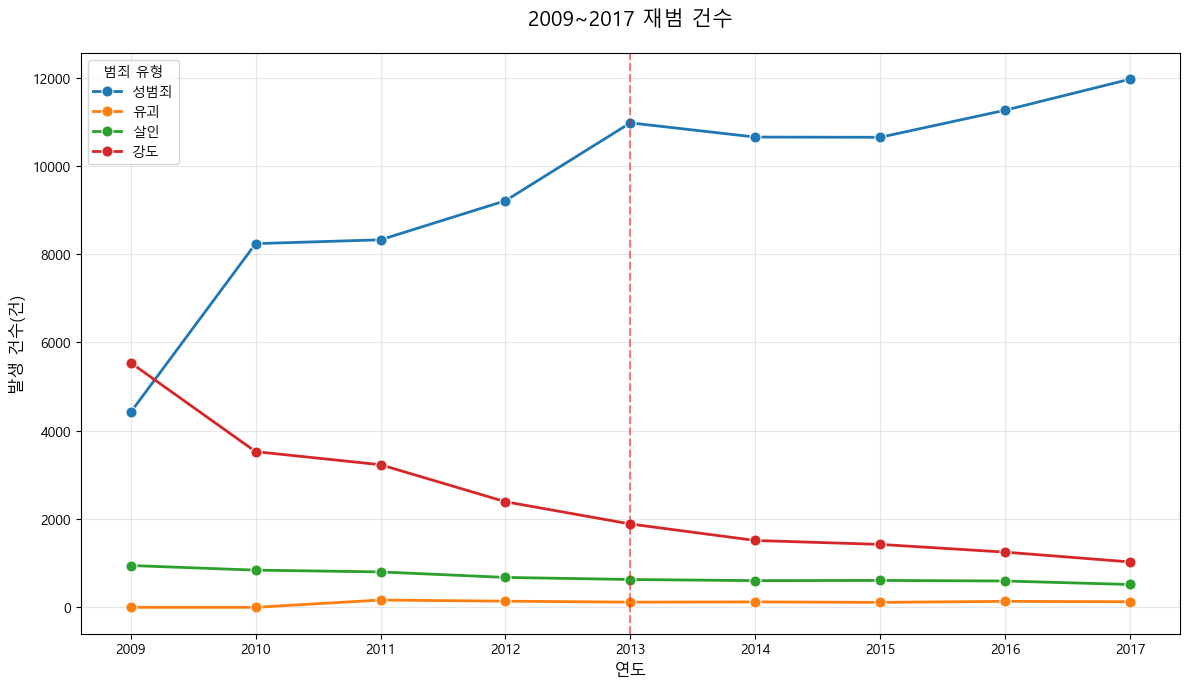

In [33]:
# =========================
# 5. 참고 시각화: 범죄 건수 
# =========================
print("연도:", years)
print("성폭력:", sexual)
print("유괴:", kidnap)
print("살인:", murder)
print("강도:", robbery)

plt.figure(figsize=(12, 7))

sns.lineplot(data=df, marker='o', markersize=8, linewidth=2, dashes=False)

plt.title('2009~2017 재범 건수', fontsize=15, pad=20)
plt.xlabel('연도', fontsize=12)
plt.ylabel('발생 건수(건)', fontsize=12)

plt.axvline('2013', linestyle='--', color='red', alpha=0.5)

plt.grid(alpha=0.3)
plt.legend(title='범죄 유형') 

plt.tight_layout()
plt.show()